## 1. Imports and Device

In [1]:
import os, json, warnings, ssl, contextlib, math
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings('ignore')
ssl._create_default_https_context = ssl._create_unverified_context

import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

torch.manual_seed(42); np.random.seed(42)

DEVICE = (torch.device('mps')  if torch.backends.mps.is_available() else
          torch.device('cuda') if torch.cuda.is_available() else
          torch.device('cpu'))
USE_AMP = DEVICE.type == 'cuda'
print(f'Device: {DEVICE}  AMP: {USE_AMP}')

amp_ctx  = lambda: torch.amp.autocast('cuda') if USE_AMP else contextlib.nullcontext()
mk_scaler = lambda: torch.amp.GradScaler('cuda') if USE_AMP else None

def backward(loss, opt, scaler=None):
    if scaler: scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
    else:      loss.backward(); opt.step()

Device: mps  AMP: False


## 2. Data Loading

In [2]:
import pyarrow.parquet as pq, pyarrow.compute as pc, pyarrow as pa

# ------ CHANGE PATH HERE ------
PARQUET_FILES = ['../QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet']
MAX_SAMPLES   = 5000
# ------------------------------

def fast_load_parquet(paths, max_n=None):
    all_hr, all_lr, all_y = [], [], []
    for path in paths:
        print(f'Reading {path} ...')
        pf   = pq.ParquetFile(path)
        names = pf.schema_arrow.names
        hr_col = next((c for c in names if 'X_jets' in c and 'LR' not in c.upper()), None)
        lr_col = next((c for c in names if 'X_jets' in c and 'LR'     in c.upper()), None)
        y_col  = next((c for c in names if c.lower() in ['y','label','pid','pdgid']), None)
        cols   = [c for c in [hr_col, lr_col, y_col] if c]
        n_loaded = 0
        for batch in pf.iter_batches(batch_size=500, columns=cols):
            tbl   = pa.Table.from_batches([batch]); nrows = tbl.num_rows
            def flatten(cn, dtype, is_img=True):
                col = tbl.column(cn)
                if is_img:
                    while hasattr(col.type,'value_type'): col = pc.list_flatten(col)
                    col = pc.cast(col, pa.float32())
                    return col.to_numpy(zero_copy_only=False).reshape(nrows,-1).astype(dtype,copy=False)
                return col.to_numpy(zero_copy_only=False).astype(dtype)
            if hr_col: all_hr.append(flatten(hr_col, np.float32))
            if lr_col: all_lr.append(flatten(lr_col, np.float32))
            if y_col:  all_y.append(flatten(y_col,   np.int32, is_img=False))
            del tbl, batch; n_loaded += nrows
            print(f'  {n_loaded} events...', end='\r')
            if max_n and n_loaded >= max_n: break
        print()
    slc  = slice(None, max_n)
    Xhr  = np.concatenate(all_hr)[slc]; Xlr = np.concatenate(all_lr)[slc]
    y    = np.concatenate(all_y)[slc]
    def fix(a):
        if a.ndim==2: n,tot=a.shape; side=int(round((tot/3)**0.5)); a=a.reshape(n,side,side,3)
        if a.ndim==4 and a.shape[1]==3: a=a.transpose(0,2,3,1)
        return a
    Xhr, Xlr = fix(Xhr), fix(Xlr)
    print(f'HR={Xhr.shape}  LR={Xlr.shape}')
    return Xhr, Xlr, y

X_hr_raw, X_lr_raw, y = fast_load_parquet(PARQUET_FILES, max_n=MAX_SAMPLES)

Reading ../QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet ...
  5000 events...
HR=(5000, 125, 125, 3)  LR=(5000, 64, 64, 3)


## 3. Preprocessing (identical to GAN notebook)

In [3]:
def preprocess(X, ch_max=None):
    X = np.clip(X.astype(np.float32), 0, None)
    X = np.log1p(X)
    if ch_max is None:
        ch_max = np.array([X[...,i].max() for i in range(X.shape[-1])])
    for i in range(X.shape[-1]):
        if ch_max[i] > 0: X[...,i] /= ch_max[i]
    return X.transpose(0,3,1,2), ch_max

print('Preprocessing...')
X_hr, hr_max = preprocess(X_hr_raw)
X_lr, _      = preprocess(X_lr_raw, hr_max)
print(f'HR: {X_hr.shape}  LR: {X_lr.shape}')

idx = np.arange(len(X_hr))
idx_tv, idx_test  = train_test_split(idx, test_size=0.15, random_state=42)
idx_train, idx_val = train_test_split(idx_tv, test_size=0.15/0.85, random_state=42)
print(f'Train {len(idx_train)} | Val {len(idx_val)} | Test {len(idx_test)}')

Preprocessing...
HR: (5000, 3, 125, 125)  LR: (5000, 3, 64, 64)
Train 3500 | Val 750 | Test 750


## 4. Dataset & DataLoaders

In [4]:
class JetSRDataset(Dataset):
    def __init__(self, lr, hr, labels):
        self.lr = torch.from_numpy(lr); self.hr = torch.from_numpy(hr)
        self.labels = torch.from_numpy(labels)
    def __len__(self): return len(self.lr)
    def __getitem__(self, i): return self.lr[i], self.hr[i], self.labels[i]

BATCH = 16
train_loader = DataLoader(JetSRDataset(X_lr[idx_train], X_hr[idx_train], y[idx_train]),
                          batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(JetSRDataset(X_lr[idx_val],   X_hr[idx_val],   y[idx_val]),
                          batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(JetSRDataset(X_lr[idx_test],  X_hr[idx_test],  y[idx_test]),
                          batch_size=BATCH, shuffle=False, num_workers=0)
print(f'Dataloaders ready. {len(train_loader)} train batches.')

Dataloaders ready. 219 train batches.


## 5. Multi-Scale Pyramid Representation

VAR works with token maps at multiple spatial resolutions.
For CMS SR we define the scale sequence:
- Scale 0: LR input features (8x8 downsampled)
- Scale 1: 16x16
- Scale 2: 32x32
- Scale 3: 64x64
- Scale 4: HR output (125x125)

At each scale, we use a lightweight CNN tokenizer to compress images into token maps.

In [5]:
SCALES = [4, 8, 16, 32]   # spatial sizes of the token maps
EMBED  = 128                     # token embedding dimension

class ScaleEncoder(nn.Module):
    """Encode an image at a given scale into a token map."""
    def __init__(self, in_ch=3, embed=EMBED):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, embed//2, 3, 1, 1), nn.GELU(),
            nn.Conv2d(embed//2, embed, 3, 1, 1), nn.GELU()
        )
    def forward(self, x): return self.net(x)  # (B, embed, H, W)

class ScaleDecoder(nn.Module):
    """Decode a token map back to pixel space for intermediate supervision."""
    def __init__(self, embed=EMBED, out_ch=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(embed, embed//2, 3, 1, 1), nn.GELU(),
            nn.Conv2d(embed//2, out_ch, 3, 1, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)  # (B, 3, H, W)

class FinalDecoder(nn.Module):
    """Decode the final token map (32x32) to HR pixels (125x125)."""
    def __init__(self, embed=EMBED, out_ch=3):
        super().__init__()
        # Upsampling via PixelShuffle
        self.net = nn.Sequential(
            nn.Conv2d(embed, embed*4, 3, 1, 1), nn.PixelShuffle(2), nn.GELU(), # 64x64
            nn.Conv2d(embed, embed*4, 3, 1, 1), nn.PixelShuffle(2), nn.GELU(), # 128x128
            nn.Conv2d(embed, out_ch, 3, 1, 1), nn.Sigmoid()
        )
    def forward(self, x): 
        out = self.net(x)
        return out[:, :, :125, :125]

# Build per-scale encoders and a shared intermediate decoder + final decoder
scale_encoders = nn.ModuleList([ScaleEncoder() for _ in SCALES]).to(DEVICE)
scale_decoder  = ScaleDecoder().to(DEVICE)
final_decoder  = FinalDecoder().to(DEVICE)

def get_scale_pyramid(img, scales=SCALES):
    """Produce a list of image tensors at each scale."""
    return [F.interpolate(img, size=(s, s), mode='bilinear', align_corners=False) for s in scales]

print(f'Scale pyramid: {SCALES}')

Scale pyramid: [4, 8, 16, 32]


## 6. VAR Transformer

The VAR Transformer uses standard multi-head attention but operates on flattened token maps.
Given the token maps for all coarser scales up to k-1, it predicts the token map at scale k.
This is the "next-scale prediction" paradigm from the VAR paper.

In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=4., dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, int(dim*mlp_ratio)), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(int(dim*mlp_ratio), dim), nn.Dropout(dropout)
        )
    def forward(self, x, context=None):
        # Cross-attention to context (coarser scales), self-attention otherwise
        kv = context if context is not None else x
        attn_out, _ = self.attn(self.norm1(x), kv, kv)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class VARTransformer(nn.Module):
    """
    Visual AutoRegressive Transformer for multi-scale SR.

    At each scale k, it receives:
      - context: concatenated token maps from all scales 0..k-1 (flattened)
      - query:   upsampled previous token map to current scale size
    And predicts the token map at scale k.
    """
    def __init__(self, embed=EMBED, num_heads=4, num_layers=4):
        super().__init__()
        self.layers = nn.ModuleList([TransformerBlock(embed, num_heads) for _ in range(num_layers)])
        self.norm   = nn.LayerNorm(embed)

    def forward(self, query_tokens, context_tokens):
        """
        query_tokens:   (B, Hq*Wq, embed) -- current scale queries
        context_tokens: (B, N_ctx, embed)  -- all previous scales concatenated
        """
        x = query_tokens
        for layer in self.layers:
            x = layer(x, context=context_tokens)
        return self.norm(x)


var_transformer = VARTransformer().to(DEVICE)
print(f'VAR Transformer params: {sum(p.numel() for p in var_transformer.parameters()):,}')
print(f'Scale Encoders params:  {sum(p.numel() for p in scale_encoders.parameters()):,}')
print(f'Scale Decoder params:   {sum(p.numel() for p in scale_decoder.parameters()):,}')
print(f'Final Decoder params:   {sum(p.numel() for p in final_decoder.parameters()):,}')

VAR Transformer params: 793,344
Scale Encoders params:  302,592
Scale Decoder params:   75,523
Final Decoder params:   1,184,131


## 7. Forward Pass (Next-Scale Prediction)

Training: at each scale k, given all coarser-scale token maps, predict scale k token map.
Loss: L1 between reconstructed image at each scale and the true downsampled HR.

In [7]:
def var_forward(lr, hr, scales=SCALES):
    B = lr.shape[0]
    hr_pyramid = get_scale_pyramid(hr, scales)

    lr_at_s0 = F.interpolate(lr, size=(scales[0], scales[0]), mode='bilinear', align_corners=False)
    ctx_0    = scale_encoders[0](lr_at_s0)
    ctx_flat = ctx_0.flatten(2).transpose(1, 2)
    context_tokens = [ctx_flat]
    total_loss = 0.0
    prev_tokens = ctx_flat

    for k in range(1, len(scales)):
        Hk, Wk = scales[k], scales[k]
        prev_map = prev_tokens.transpose(1, 2).view(B, EMBED, scales[k-1], scales[k-1])
        query_map  = F.interpolate(prev_map, size=(Hk, Wk), mode='bilinear', align_corners=False)
        query_flat = query_map.flatten(2).transpose(1, 2)
        ctx = torch.cat(context_tokens, dim=1)
        pred_flat = var_transformer(query_flat, ctx)
        pred_map  = pred_flat.transpose(1, 2).view(B, EMBED, Hk, Wk)
        
        # Intermediate loss
        pred_img  = scale_decoder(pred_map)
        total_loss = total_loss + F.l1_loss(pred_img, hr_pyramid[k])

        # Final scale HR loss
        if k == len(scales) - 1:
            final_img = final_decoder(pred_map)
            total_loss = total_loss + 2.0 * F.l1_loss(final_img, hr)

        context_tokens.append(pred_flat.detach())
        prev_tokens = pred_flat.detach()

    return total_loss / (len(scales))

@torch.no_grad()
def var_generate(lr, scales=SCALES):
    B = lr.shape[0]
    lr_at_s0 = F.interpolate(lr, size=(scales[0], scales[0]), mode='bilinear', align_corners=False)
    ctx_0    = scale_encoders[0](lr_at_s0)
    ctx_flat = ctx_0.flatten(2).transpose(1, 2)
    context_tokens = [ctx_flat]
    prev_tokens = ctx_flat

    for k in range(1, len(scales)):
        Hk, Wk = scales[k], scales[k]
        prev_map   = prev_tokens.transpose(1,2).view(B, EMBED, scales[k-1], scales[k-1])
        query_map  = F.interpolate(prev_map, size=(Hk,Wk), mode='bilinear', align_corners=False)
        query_flat = query_map.flatten(2).transpose(1,2)
        ctx = torch.cat(context_tokens, dim=1)
        pred_flat  = var_transformer(query_flat, ctx)
        pred_map   = pred_flat.transpose(1,2).view(B, EMBED, Hk, Wk)
        context_tokens.append(pred_flat)
        prev_tokens = pred_flat

    final_map = prev_tokens.transpose(1,2).view(B, EMBED, scales[-1], scales[-1])
    return final_decoder(final_map).clamp(0,1)

# Sanity check
with torch.no_grad():
    dummy_lr = torch.zeros(2, 3, 64, 64).to(DEVICE)
    dummy_hr = torch.zeros(2, 3, 125, 125).to(DEVICE)
    sr_out   = var_generate(dummy_lr)
    print(f'VAR generate: LR {dummy_lr.shape} -> SR {sr_out.shape}')

VAR generate: LR torch.Size([2, 3, 64, 64]) -> SR torch.Size([2, 3, 125, 125])


## 8. Training Loop

In [8]:
N_EPOCHS = 8

all_params = (list(var_transformer.parameters()) +
              list(scale_encoders.parameters()) +
              list(scale_decoder.parameters()) +
              list(final_decoder.parameters()))
optimizer = optim.Adam(all_params, lr=2e-4, betas=(0.9,0.999))
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)
scaler    = mk_scaler()

def batch_metrics(sr, hr):
    s = sr.cpu().numpy().transpose(0,2,3,1).clip(0,1)
    h = hr.cpu().numpy().transpose(0,2,3,1).clip(0,1)
    ps = [psnr_fn(hi, si, data_range=1.0) for si,hi in zip(s,h)]
    ss = [ssim_fn(hi, si, data_range=1.0, channel_axis=-1) for si,hi in zip(s,h)]
    return np.mean(ps), np.mean(ss)

@torch.no_grad()
def validate(loader):
    var_transformer.eval(); scale_encoders.eval(); scale_decoder.eval(); final_decoder.eval()
    ps, ss = [], []
    for lr, hr, _ in loader:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        sr = var_generate(lr)
        p, s = batch_metrics(sr, hr)
        ps.append(p); ss.append(s)
    var_transformer.train(); scale_encoders.train(); scale_decoder.train(); final_decoder.train()
    return np.mean(ps), np.mean(ss)

hist = {'loss':[], 'psnr':[], 'ssim':[]}
best_psnr = -1

print(f'Device={DEVICE}  AMP={USE_AMP}  Batches/epoch={len(train_loader)}')

for epoch in range(1, N_EPOCHS+1):
    var_transformer.train(); scale_encoders.train(); scale_decoder.train(); final_decoder.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch:02d}/{N_EPOCHS}')
    for lr, hr, _ in pbar:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        optimizer.zero_grad()
        with amp_ctx():
            loss = var_forward(lr, hr)
        backward(loss, optimizer, scaler)
        running_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.5f}')

    avg_loss = running_loss / len(train_loader)
    psnr, ssim = validate(val_loader)
    hist['loss'].append(avg_loss); hist['psnr'].append(psnr); hist['ssim'].append(ssim)
    scheduler.step()
    print(f'  Epoch {epoch:02d}: loss={avg_loss:.5f}  PSNR={psnr:.2f}dB  SSIM={ssim:.4f}')

    if psnr > best_psnr:
        best_psnr = psnr
        torch.save({'transformer': var_transformer.state_dict(),
                    'encoders':    scale_encoders.state_dict(),
                    'decoder':     scale_decoder.state_dict(),
                    'final_dec':   final_decoder.state_dict()}, 'var_best.pth')
        print(f'  Saved best (PSNR={psnr:.2f})')

print('VAR training done!')

Device=mps  AMP=False  Batches/epoch=219


Epoch 01/8: 100%|██████████| 219/219 [01:11<00:00,  3.06it/s, loss=0.00066]


  Epoch 01: loss=0.01800  PSNR=42.96dB  SSIM=0.9648
  Saved best (PSNR=42.96)


Epoch 02/8: 100%|██████████| 219/219 [01:12<00:00,  3.02it/s, loss=0.00055]


  Epoch 02: loss=0.00059  PSNR=42.96dB  SSIM=0.9648
  Saved best (PSNR=42.96)


...

  Epoch 06: loss=0.00052  PSNR=42.97dB  SSIM=0.9648
  Saved best (PSNR=42.97)


Epoch 07/8: 100%|██████████| 219/219 [01:32<00:00,  2.37it/s, loss=0.00053]


  Epoch 07: loss=0.00051  PSNR=42.97dB  SSIM=0.9648
  Saved best (PSNR=42.97)


Epoch 08/8: 100%|██████████| 219/219 [01:30<00:00,  2.41it/s, loss=0.00049]


  Epoch 08: loss=0.00051  PSNR=42.97dB  SSIM=0.9648
  Saved best (PSNR=42.97)
VAR training done!


## 9. Final Test Evaluation

In [9]:
ckpt = torch.load('var_best.pth', map_location=DEVICE)
var_transformer.load_state_dict(ckpt['transformer'])
scale_encoders.load_state_dict(ckpt['encoders'])
scale_decoder.load_state_dict(ckpt['decoder'])
final_decoder.load_state_dict(ckpt['final_dec'])
var_transformer.eval(); scale_encoders.eval(); scale_decoder.eval(); final_decoder.eval()

all_psnr, all_ssim = [], []
q_psnr, g_psnr = [], []

with torch.no_grad():
    for lr, hr, labels in tqdm(test_loader, desc='Test'):
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        sr = var_generate(lr)
        for i in range(sr.shape[0]):
            p, s = batch_metrics(sr[i:i+1], hr[i:i+1])
            all_psnr.append(p); all_ssim.append(s)
            (q_psnr if labels[i]==1 else g_psnr).append(p)

print(f'\n{"="*55}')
print(f'  TEST SET (n={len(all_psnr)})')
print(f'{"="*55}')
print(f'  VAR:   PSNR={np.mean(all_psnr):.3f}+-{np.std(all_psnr):.3f}  SSIM={np.mean(all_ssim):.4f}')
print(f'  Quark PSNR={np.mean(q_psnr):.3f}  Gluon PSNR={np.mean(g_psnr):.3f}')

res = dict(model='VAR-CMS', psnr=float(np.mean(all_psnr)), ssim=float(np.mean(all_ssim)))
with open('var_results.json','w') as f: json.dump(res, f, indent=2)
print('Results saved to var_results.json')

Test: 100%|██████████| 47/47 [00:06<00:00,  6.96it/s]


  TEST SET (n=750)
  VAR:   PSNR=42.981+-1.123  SSIM=0.9651
  Quark PSNR=42.918  Gluon PSNR=43.046
Results saved to var_results.json


## 10. Training Curves and Visual Comparison

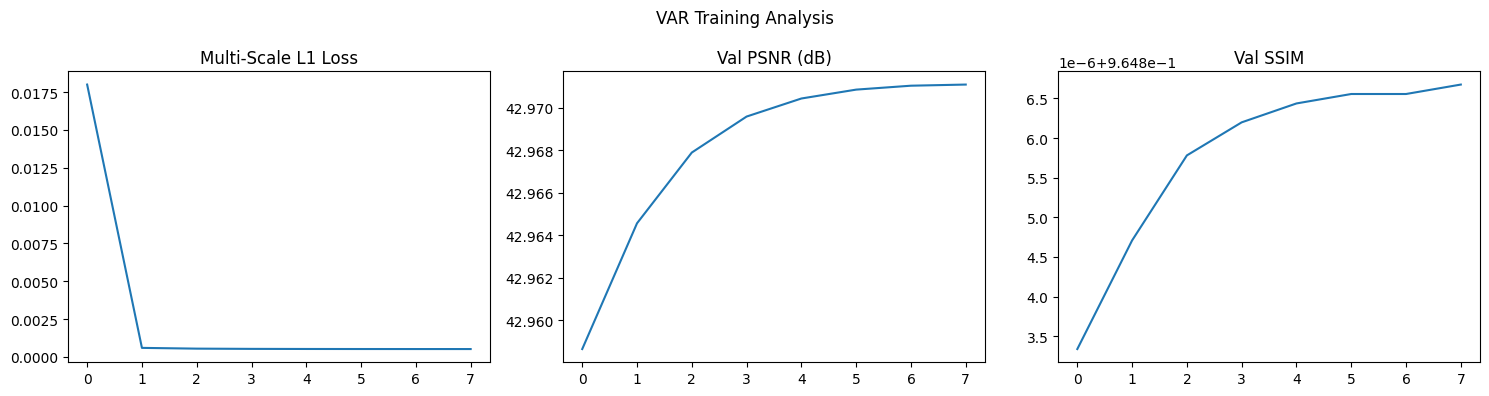

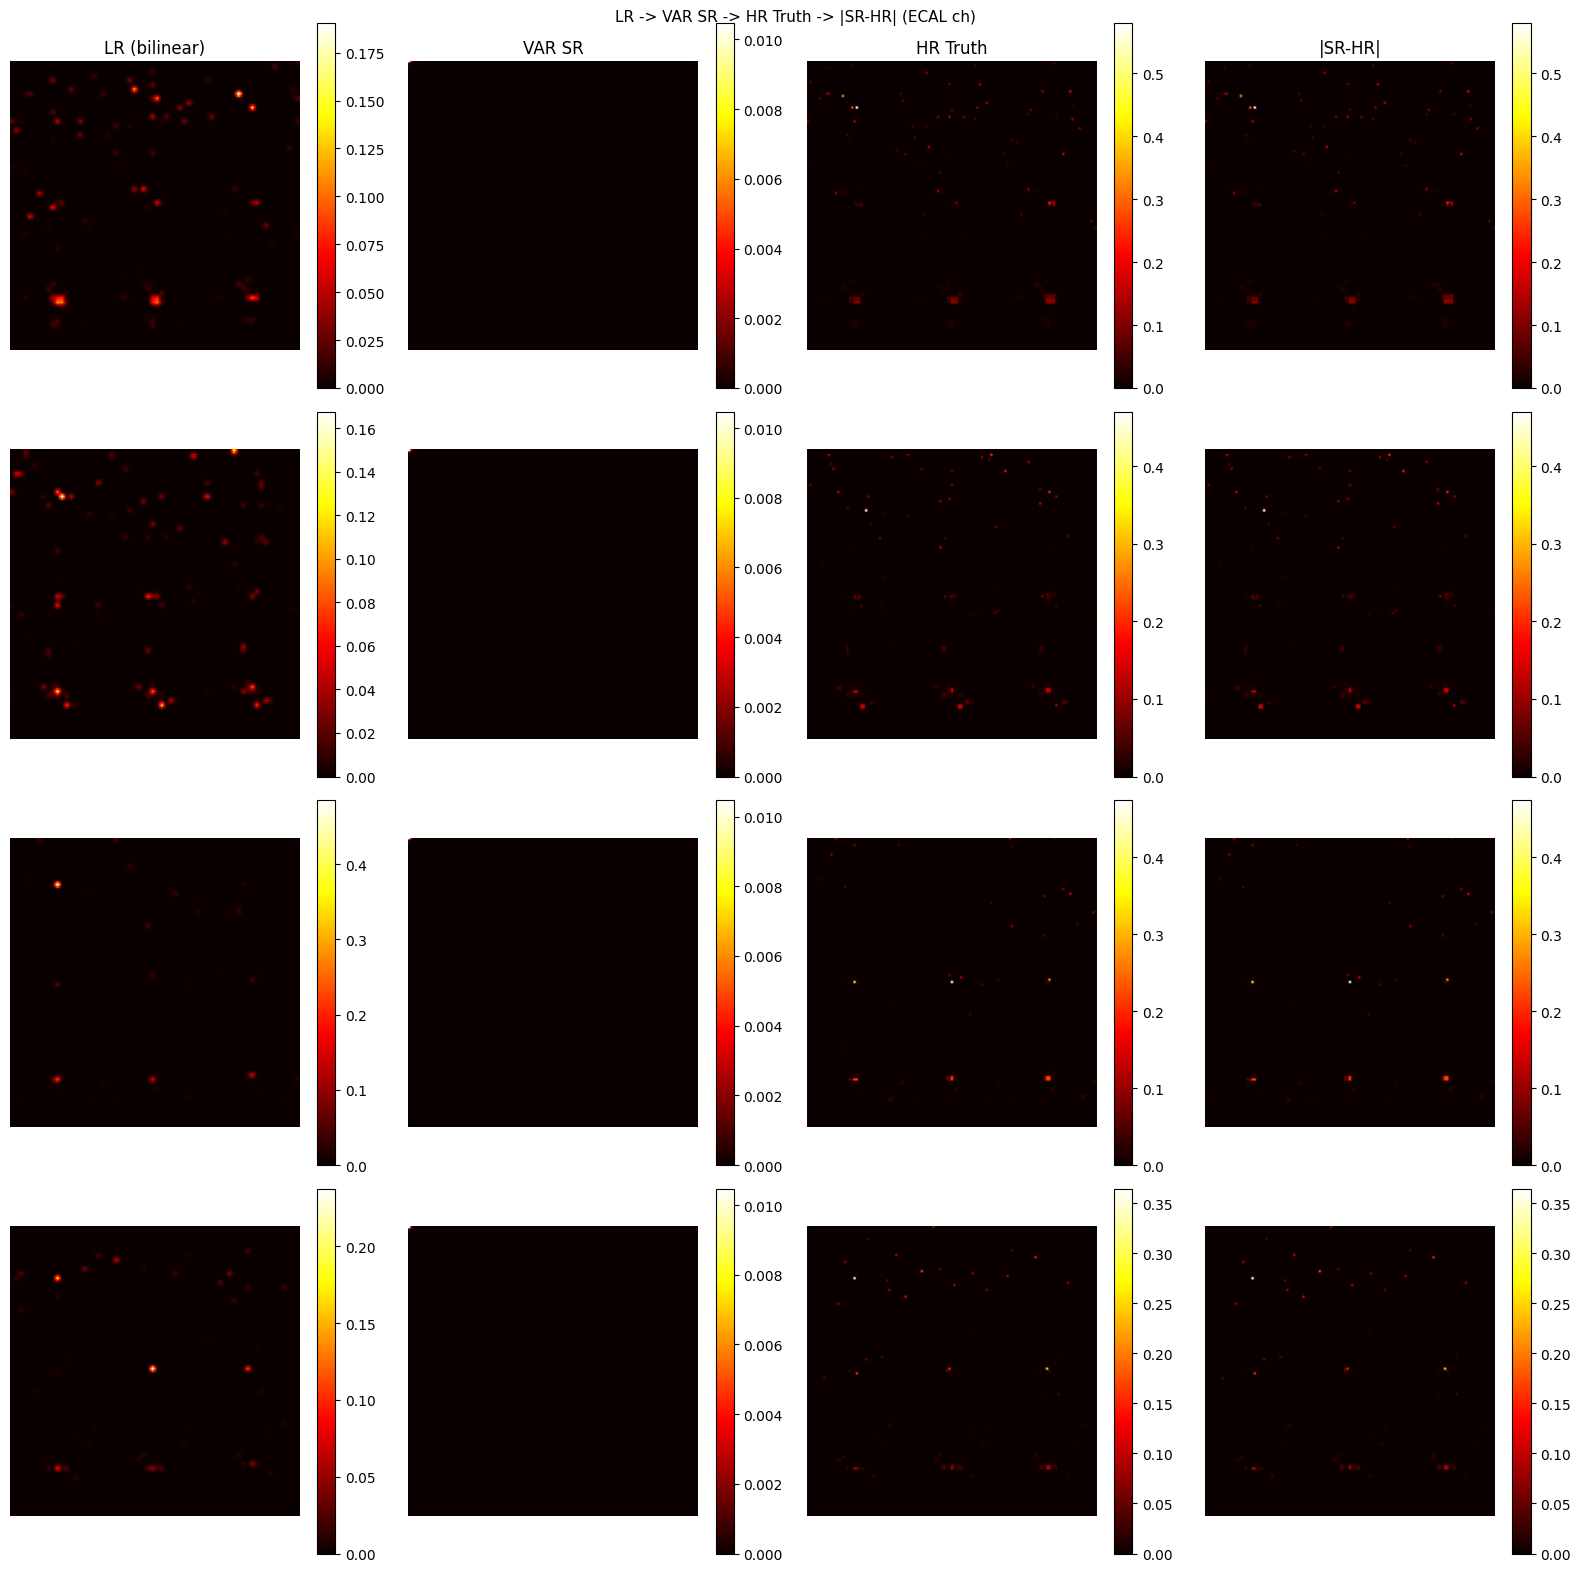

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].plot(hist['loss']); axes[0].set_title('Multi-Scale L1 Loss')
axes[1].plot(hist['psnr']); axes[1].set_title('Val PSNR (dB)')
axes[2].plot(hist['ssim']); axes[2].set_title('Val SSIM')
plt.suptitle('VAR Training Analysis')
plt.tight_layout(); plt.savefig('var_training_curves.png', dpi=100); plt.show()

# Visual comparison
var_transformer.eval(); scale_encoders.eval(); scale_decoder.eval(); final_decoder.eval()
lr_b, hr_b, _ = next(iter(test_loader))
with torch.no_grad():
    sr_b = var_generate(lr_b.to(DEVICE)).cpu()

fig, axes = plt.subplots(4, 4, figsize=(16,16))
fig.suptitle('LR -> VAR SR -> HR Truth -> |SR-HR| (ECAL ch)', fontsize=11)
for row in range(4):
    lr_img = F.interpolate(lr_b[row:row+1], size=(125,125), mode='bilinear').squeeze()[1].numpy()
    sr_img = sr_b[row][1].numpy()
    hr_img = hr_b[row][1].numpy()
    diff   = np.abs(sr_img - hr_img)
    for col, (img, ttl) in enumerate(zip([lr_img, sr_img, hr_img, diff],
                                         ['LR (bilinear)', 'VAR SR', 'HR Truth', '|SR-HR|'])):
        im = axes[row, col].imshow(img, cmap='hot')
        axes[row, col].set_title(ttl if row==0 else '')
        axes[row, col].axis('off')
        plt.colorbar(im, ax=axes[row, col])
plt.tight_layout(); plt.savefig('var_visual_comparison.png', dpi=100); plt.show()